In [4]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [5]:
import sys
import subprocess
import importlib

required = ['xgboost', 'networkx', 'matplotlib']
missing = []
for pkg in required:
    try:
        importlib.import_module(pkg)
    except ImportError:
        missing.append(pkg)

if missing:
    print(f"Installing missing packages: {missing}")
    subprocess.check_call([sys.executable, "-m", "pip", "install"] + missing)
else:
    print("All required packages already installed.")

All required packages already installed.


In [3]:
!pip install torch_geometric

In [6]:
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
import networkx as nx
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score, average_precision_score, accuracy_score
from xgboost import XGBClassifier
from torch_geometric.data import Data
from torch_geometric.nn import GCNConv, SAGEConv, GATConv
import warnings
warnings.filterwarnings('ignore')

# Device selection
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

c:\Users\Vishal\.conda\envs\gnn_crypto\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cuda


In [1]:
import pandas as pd
from pathlib import Path

# Project folder
DATA_DIR = Path(r"D:\code\python\chd")

# Load dataset files
df_feat = pd.read_csv(
    DATA_DIR / "elliptic_txs_features.csv",
    header=None
)

df_cls = pd.read_csv(
    DATA_DIR / "elliptic_txs_classes.csv"
)

df_edges = pd.read_csv(
    DATA_DIR / "elliptic_txs_edgelist.csv"
)

# Number of transaction features
n_feat = df_feat.shape[1] - 2

# Set column names
df_feat.columns = (
    ['txId', 'timestep'] +
    [f'f_{i}' for i in range(n_feat)]
)

# Merge transaction features with classes
df = df_feat.merge(df_cls, on='txId', how='left')

# Convert labels:
# 1 = illicit/suspicious
# 2 = licit/normal
# unknown = -1
df['label'] = (
    df['class']
    .map({'1': 1, '2': 0})
    .fillna(-1)
    .astype(int)
)

print(f"Total nodes: {len(df)}")
print("\nLabel distribution:")
print(df['label'].value_counts())

Total nodes: 203769

Label distribution:
label
-1    157205
 0     42019
 1      4545
Name: count, dtype: int64


C:\Users\Vishal\AppData\Local\Temp\ipykernel_9164\2021275505.py:37: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['label'] = (


In [37]:
from sklearn.preprocessing import StandardScaler
import torch

# ============================================================
# SCALE USING TRAINING DATA ONLY
# ============================================================

scaler = StandardScaler()

# Fit ONLY on training transactions
X_train = X[train_mask]

print("Fitting scaler on training data...")
scaler.fit(X_train)

# Transform all transactions using training statistics
X_scaled = scaler.transform(X).astype(np.float32)

# Labels
y_tensor = torch.tensor(
    df["label"].values,
    dtype=torch.long
)

print("Scaler fitted on training data only.")
print("Feature matrix:", X_scaled.shape)
print("Training samples:", X_train.shape[0])
print("Feature dtype:", X_scaled.dtype)

Fitting scaler on training data...
Scaler fitted on training data only.
Feature matrix: (203769, 102)
Training samples: 29894
Feature dtype: float32


In [36]:
tx_to_idx = {tx: i for i, tx in enumerate(df['txId'].values)}
src = [tx_to_idx[tx] for tx in df_edges['txId1']]
dst = [tx_to_idx[tx] for tx in df_edges['txId2']]
edge_index = torch.tensor([src, dst], dtype=torch.long)
print(f" Directed edges: {edge_index.shape[1]}")

 Directed edges: 234355


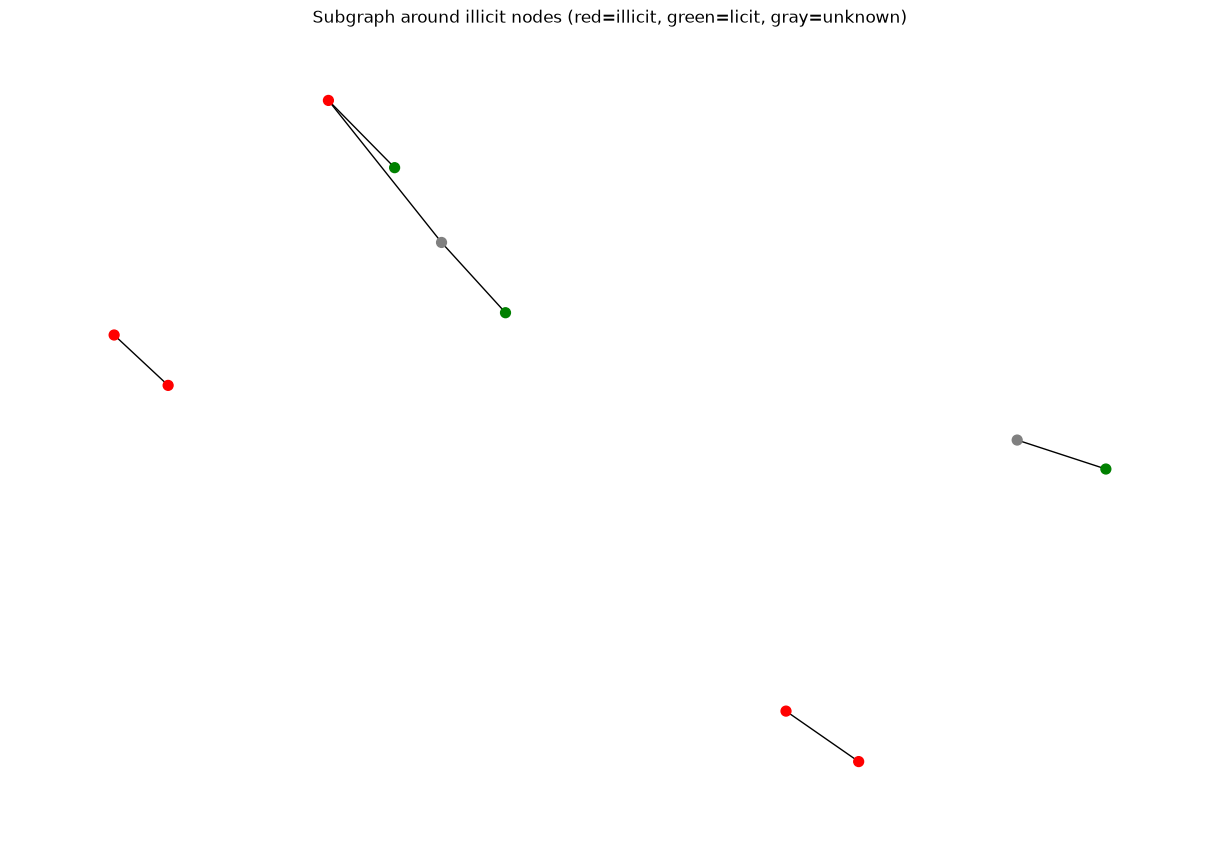

In [8]:
illicit_ids = df[df['label'] == 1]['txId'].values[:5]
if len(illicit_ids) > 0:
    illicit_indices = [tx_to_idx[t] for t in illicit_ids if t in tx_to_idx]
    neighbours = set()
    for idx in illicit_indices:
        neighbours.add(idx)
        for i in range(len(src)):
            if src[i] == idx:
                neighbours.add(dst[i])
            if dst[i] == idx:
                neighbours.add(src[i])
    if len(neighbours) > 500:
        neighbours = set(list(neighbours)[:500])
    sub_nodes = list(neighbours)
    sub_idx = {node: i for i, node in enumerate(sub_nodes)}
    sub_src = []
    sub_dst = []
    for i in range(len(src)):
        if src[i] in sub_nodes and dst[i] in sub_nodes:
            sub_src.append(sub_idx[src[i]])
            sub_dst.append(sub_idx[dst[i]])
    G_sub = nx.DiGraph()
    G_sub.add_edges_from(zip(sub_src, sub_dst))
    node_colors = []
    for node in sub_nodes:
        label = df.iloc[node]['label']
        if label == 1:
            node_colors.append('red')
        elif label == 0:
            node_colors.append('green')
        else:
            node_colors.append('gray')
    plt.figure(figsize=(12, 8))
    pos = nx.spring_layout(G_sub, seed=42)
    nx.draw(G_sub, pos, node_color=node_colors, node_size=50, with_labels=False, arrows=False)
    plt.title("Subgraph around illicit nodes (red=illicit, green=licit, gray=unknown)")
    plt.show()
else:
    print("No illicit nodes found for visualisation.")

In [35]:
# ============================================================
# TEMPORAL-SAFE GRAPH FEATURES
# Only information available up to each transaction's timestep
# ============================================================

import numpy as np
import pandas as pd

print("Computing temporal graph features...")

# ------------------------------------------------------------
# 1. Original 94 transaction features
# ------------------------------------------------------------
local_cols = [f'f_{i}' for i in range(94)]

X_local = (
    df[local_cols]
    .fillna(0)
    .astype(np.float32)
    .values
)

# ------------------------------------------------------------
# 2. Create edge dataframe
# ------------------------------------------------------------
edges = pd.DataFrame({
    "src": src,
    "dst": dst
})

# Map transaction ID -> dataframe row index
tx_to_idx = {
    tx_id: idx
    for idx, tx_id in enumerate(df["txId"].values)
}

edges["src_idx"] = edges["src"].map(tx_to_idx)
edges["dst_idx"] = edges["dst"].map(tx_to_idx)

# Remove edges that cannot be mapped
edges = edges.dropna(subset=["src_idx", "dst_idx"]).copy()

edges["src_idx"] = edges["src_idx"].astype(np.int32)
edges["dst_idx"] = edges["dst_idx"].astype(np.int32)

# Timestep of each edge's source/destination
edges["src_time"] = df["timestep"].values[edges["src_idx"]]
edges["dst_time"] = df["timestep"].values[edges["dst_idx"]]

# Edge is available when both transactions are known
edges["edge_time"] = np.maximum(
    edges["src_time"],
    edges["dst_time"]
)

# ------------------------------------------------------------
# 3. Allocate temporal features
# ------------------------------------------------------------
n = len(df)

hist_in_degree = np.zeros(n, dtype=np.float32)
hist_out_degree = np.zeros(n, dtype=np.float32)
hist_degree = np.zeros(n, dtype=np.float32)
hist_ratio = np.zeros(n, dtype=np.float32)
hist_neighbor_degree = np.zeros(n, dtype=np.float32)

# ------------------------------------------------------------
# 4. Calculate features timestep by timestep
# ------------------------------------------------------------
timesteps = sorted(df["timestep"].unique())

for t in timesteps:

    node_mask = (df["timestep"].values == t)
    node_indices = np.where(node_mask)[0]

    # Only edges available at or before timestep t
    available_edges = edges[
        edges["edge_time"] <= t
    ]

    # Historical degrees
    in_deg = np.bincount(
        available_edges["dst_idx"].values,
        minlength=n
    ).astype(np.float32)

    out_deg = np.bincount(
        available_edges["src_idx"].values,
        minlength=n
    ).astype(np.float32)

    total_deg = in_deg + out_deg

    ratio = in_deg / (out_deg + 1.0)

    hist_in_degree[node_indices] = in_deg[node_indices]
    hist_out_degree[node_indices] = out_deg[node_indices]
    hist_degree[node_indices] = total_deg[node_indices]
    hist_ratio[node_indices] = ratio[node_indices]

    # Neighbor degree
    neighbor_sum = np.zeros(n, dtype=np.float32)
    neighbor_count = np.zeros(n, dtype=np.float32)

    s = available_edges["src_idx"].values
    d = available_edges["dst_idx"].values

    # Treat graph as undirected for neighborhood statistics
    np.add.at(neighbor_sum, s, total_deg[d])
    np.add.at(neighbor_sum, d, total_deg[s])

    np.add.at(neighbor_count, s, 1)
    np.add.at(neighbor_count, d, 1)

    neighbor_mean = neighbor_sum / np.maximum(neighbor_count, 1)

    hist_neighbor_degree[node_indices] = neighbor_mean[node_indices]

    print(f"Processed timestep {t}")

# ------------------------------------------------------------
# 5. Log transforms
# ------------------------------------------------------------
log_hist_degree = np.log1p(hist_degree)
log_hist_in_degree = np.log1p(hist_in_degree)
log_hist_out_degree = np.log1p(hist_out_degree)

# ------------------------------------------------------------
# 6. Combine features
# ------------------------------------------------------------
engineered_cols = [
    "hist_in_degree",
    "hist_out_degree",
    "hist_degree",
    "hist_in_out_ratio",
    "hist_neighbor_degree",
    "log_hist_degree",
    "log_hist_in_degree",
    "log_hist_out_degree"
]

X_engineered = np.column_stack([
    hist_in_degree,
    hist_out_degree,
    hist_degree,
    hist_ratio,
    hist_neighbor_degree,
    log_hist_degree,
    log_hist_in_degree,
    log_hist_out_degree
]).astype(np.float32)

X = np.hstack([
    X_local,
    X_engineered
]).astype(np.float32)

print("\nTemporal feature engineering complete.")
print(f"Original features: {X_local.shape[1]}")
print(f"Engineered features: {X_engineered.shape[1]}")
print(f"Total features: {X.shape[1]}")
print(f"Feature matrix shape: {X.shape}")

Computing temporal graph features...
Processed timestep 1
Processed timestep 2
Processed timestep 3
Processed timestep 4
Processed timestep 5
Processed timestep 6
Processed timestep 7
Processed timestep 8
Processed timestep 9
Processed timestep 10
Processed timestep 11
Processed timestep 12
Processed timestep 13
Processed timestep 14
Processed timestep 15
Processed timestep 16
Processed timestep 17
Processed timestep 18
Processed timestep 19
Processed timestep 20
Processed timestep 21
Processed timestep 22
Processed timestep 23
Processed timestep 24
Processed timestep 25
Processed timestep 26
Processed timestep 27
Processed timestep 28
Processed timestep 29
Processed timestep 30
Processed timestep 31
Processed timestep 32
Processed timestep 33
Processed timestep 34
Processed timestep 35
Processed timestep 36
Processed timestep 37
Processed timestep 38
Processed timestep 39
Processed timestep 40
Processed timestep 41
Processed timestep 42
Processed timestep 43
Processed timestep 44
Proc

In [34]:
print("src:", type(src), len(src))
print("dst:", type(dst), len(dst))
print("timesteps:", df["timestep"].min(), "to", df["timestep"].max())
print("columns:", df.columns.tolist())

src: <class 'list'> 234355
dst: <class 'list'> 234355
timesteps: 1 to 49
columns: ['txId', 'timestep', 'f_0', 'f_1', 'f_2', 'f_3', 'f_4', 'f_5', 'f_6', 'f_7', 'f_8', 'f_9', 'f_10', 'f_11', 'f_12', 'f_13', 'f_14', 'f_15', 'f_16', 'f_17', 'f_18', 'f_19', 'f_20', 'f_21', 'f_22', 'f_23', 'f_24', 'f_25', 'f_26', 'f_27', 'f_28', 'f_29', 'f_30', 'f_31', 'f_32', 'f_33', 'f_34', 'f_35', 'f_36', 'f_37', 'f_38', 'f_39', 'f_40', 'f_41', 'f_42', 'f_43', 'f_44', 'f_45', 'f_46', 'f_47', 'f_48', 'f_49', 'f_50', 'f_51', 'f_52', 'f_53', 'f_54', 'f_55', 'f_56', 'f_57', 'f_58', 'f_59', 'f_60', 'f_61', 'f_62', 'f_63', 'f_64', 'f_65', 'f_66', 'f_67', 'f_68', 'f_69', 'f_70', 'f_71', 'f_72', 'f_73', 'f_74', 'f_75', 'f_76', 'f_77', 'f_78', 'f_79', 'f_80', 'f_81', 'f_82', 'f_83', 'f_84', 'f_85', 'f_86', 'f_87', 'f_88', 'f_89', 'f_90', 'f_91', 'f_92', 'f_93', 'f_94', 'f_95', 'f_96', 'f_97', 'f_98', 'f_99', 'f_100', 'f_101', 'f_102', 'f_103', 'f_104', 'f_105', 'f_106', 'f_107', 'f_108', 'f_109', 'f_110', 'f_111',

In [12]:
timesteps = df['timestep'].values
train_mask = (timesteps <= 34) & (df['label'] != -1)
val_mask   = (timesteps >= 35) & (timesteps <= 38) & (df['label'] != -1)
test_mask  = (timesteps >= 39) & (timesteps <= 49) & (df['label'] != -1)

train_mask_pt = torch.tensor(train_mask.values)
val_mask_pt   = torch.tensor(val_mask.values)
test_mask_pt  = torch.tensor(test_mask.values)

train_idx = torch.nonzero(train_mask_pt).squeeze()
val_idx   = torch.nonzero(val_mask_pt).squeeze()
test_idx  = torch.nonzero(test_mask_pt).squeeze()

print(f"Train nodes: {len(train_idx)} (licit={df['label'][train_mask].value_counts().get(0,0)}, illicit={df['label'][train_mask].value_counts().get(1,0)})")
print(f" Val nodes:   {len(val_idx)}   (licit={df['label'][val_mask].value_counts().get(0,0)}, illicit={df['label'][val_mask].value_counts().get(1,0)})")
print(f"Test nodes:  {len(test_idx)}  (licit={df['label'][test_mask].value_counts().get(0,0)}, illicit={df['label'][test_mask].value_counts().get(1,0)})")

Train nodes: 29894 (licit=26432, illicit=3462)
 Val nodes:   4303   (licit=3937, illicit=366)
Test nodes:  12367  (licit=11650, illicit=717)


In [38]:
from torch_geometric.data import Data

x_tensor = torch.tensor(X_scaled, dtype=torch.float32)

data = Data(
    x=x_tensor,
    edge_index=edge_index,
    y=y_tensor
).to(device)

print(data)
print("Nodes:", data.num_nodes)
print("Edges:", data.num_edges)
print("Features:", data.num_features)
print("X device:", data.x.device)
print("Y device:", data.y.device)

Data(x=[203769, 102], edge_index=[2, 234355], y=[203769])
Nodes: 203769
Edges: 234355
Features: 102
X device: cuda:0
Y device: cuda:0


In [25]:
def compute_class_weights():
    train_labels = df['label'].values[train_idx.numpy()]
    n_0 = np.sum(train_labels == 0)
    n_1 = np.sum(train_labels == 1)
    weight_0 = 1.0 / n_0
    weight_1 = 1.0 / n_1
    total = weight_0 + weight_1
    return torch.tensor([weight_0/total, weight_1/total], dtype=torch.float)

def focal_loss(pred, target, alpha=None, gamma=2.0, reduction='mean'):
    ce_loss = F.cross_entropy(pred, target, reduction='none')
    p_t = torch.exp(-ce_loss)
    focal_weight = (1 - p_t) ** gamma
    if alpha is not None:
        alpha_t = alpha[target]
        focal_weight = alpha_t * focal_weight
    loss = focal_weight * ce_loss
    return loss.mean() if reduction == 'mean' else loss.sum()

def find_best_threshold(y_true, y_prob, steps=100):
    best_f1 = 0
    best_th = 0.5
    for th in np.linspace(0.1, 0.9, steps):
        pred = (y_prob > th).astype(int)
        f1 = f1_score(y_true, pred, zero_division=0)
        if f1 > best_f1:
            best_f1 = f1
            best_th = th
    return best_th, best_f1

def evaluate(model, data, mask, threshold=0.5):
    model.eval()
    with torch.no_grad():
        out = model(data)
        probas = torch.softmax(out, dim=1)[:, 1].cpu().numpy()
    y_true = data.y[mask].cpu().numpy()
    prob = probas[mask.cpu().numpy()]
    pred = (prob > threshold).astype(int)
    f1 = f1_score(y_true, pred, zero_division=0)
    pr_auc = average_precision_score(y_true, prob)
    acc = accuracy_score(y_true, pred)
    return f1, pr_auc, acc

In [18]:
class GCN(torch.nn.Module):
    def __init__(self, in_dim, hidden_dim=512, out_dim=2, dropout=0.5):
        super().__init__()
        self.conv1 = GCNConv(in_dim, hidden_dim)
        self.bn1 = torch.nn.BatchNorm1d(hidden_dim)
        self.conv2 = GCNConv(hidden_dim, hidden_dim)
        self.bn2 = torch.nn.BatchNorm1d(hidden_dim)
        self.conv3 = GCNConv(hidden_dim, out_dim)
        self.dropout = dropout

    def forward(self, data):
        x, edge_index = data.x, data.edge_index
        x = self.conv1(x, edge_index)
        x = self.bn1(x)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.conv2(x, edge_index)
        x = self.bn2(x)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.conv3(x, edge_index)
        return x

class GraphSAGE(torch.nn.Module):
    def __init__(self, in_dim, hidden_dim=512, out_dim=2, dropout=0.5):
        super().__init__()
        self.conv1 = SAGEConv(in_dim, hidden_dim, aggr='max')
        self.bn1 = torch.nn.BatchNorm1d(hidden_dim)
        self.conv2 = SAGEConv(hidden_dim, hidden_dim, aggr='max')
        self.bn2 = torch.nn.BatchNorm1d(hidden_dim)
        self.conv3 = SAGEConv(hidden_dim, out_dim, aggr='max')
        self.dropout = dropout

    def forward(self, data):
        x, edge_index = data.x, data.edge_index
        x = self.conv1(x, edge_index)
        x = self.bn1(x)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.conv2(x, edge_index)
        x = self.bn2(x)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.conv3(x, edge_index)
        return x

class GAT(torch.nn.Module):
    def __init__(self, in_dim, hidden_dim=512, out_dim=2, heads=8, dropout=0.5):
        super().__init__()
        self.conv1 = GATConv(in_dim, hidden_dim // heads, heads=heads, dropout=dropout)
        self.bn1 = torch.nn.BatchNorm1d(hidden_dim)
        self.conv2 = GATConv(hidden_dim, hidden_dim // heads, heads=heads, dropout=dropout)
        self.bn2 = torch.nn.BatchNorm1d(hidden_dim)
        self.conv3 = GATConv(hidden_dim, out_dim, heads=1, dropout=dropout)
        self.dropout = dropout

    def forward(self, data):
        x, edge_index = data.x, data.edge_index
        x = self.conv1(x, edge_index)
        x = self.bn1(x)
        x = F.elu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.conv2(x, edge_index)
        x = self.bn2(x)
        x = F.elu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.conv3(x, edge_index)
        return x

In [23]:
def train_model(model, data, optimizer, scheduler, epochs=300, patience=50, gamma=2.0):
    best_val_f1 = 0
    best_epoch = 0
    best_model_state = None
    alpha = compute_class_weights().to(device)

    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()
        out = model(data)
        loss = focal_loss(out[train_mask_pt], data.y[train_mask_pt], alpha=alpha, gamma=gamma)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        if epoch % 5 == 0:
            f1_val, _, _ = evaluate(model, data, val_mask_pt, threshold=0.5)
            if f1_val > best_val_f1:
                best_val_f1 = f1_val
                best_epoch = epoch
                best_model_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
                print(f"Epoch {epoch:3d} | Loss: {loss.item():.4f} | Val F1: {f1_val:.4f}")
            scheduler.step(f1_val)

        if epoch - best_epoch >= patience:
            print(f"Early stopping at epoch {epoch}")
            break

    model.load_state_dict(best_model_state)
    return model

In [26]:
print("\n=== Hyperparameter Tuning (GraphSAGE) ===")
best_val_f1 = 0.7232
best_params = {'hidden_dim': 512, 'lr': 0.001, 'dropout': 0.4, 'gamma': 2.0, 'best_val_f1' :best_val_f1 }
print("Best GraphSAGE configuration:")
print(best_params)
# Use hidden_dim up to 512 (or 768 if memory permits) – 1024 causes OOM
# for hidden_dim in [512]:
    # for lr in [0.001, 0.0003]:
    #     for dropout in [0.4, 0.5, 0.6]:
    #         for gamma in [2.0, 3.0]:
    #             model = GraphSAGE(data.num_features, hidden_dim=hidden_dim, dropout=dropout).to(device)
    #             optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-3)
    #             scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=15)
    #             model = train_model(model, data, optimizer, scheduler, epochs=300, patience=50, gamma=gamma)
    #             f1_val, _, _ = evaluate(model, data, val_mask_pt, threshold=0.5)
    #             if f1_val > best_val_f1:
    #                 best_val_f1 = f1_val
    #                 best_params = {'hidden_dim': hidden_dim, 'lr': lr, 'dropout': dropout, 'gamma': gamma}
    #             print(f"Params: {hidden_dim}, {lr}, {dropout}, {gamma} -> Val F1: {f1_val:.4f}")
    #             # Clear GPU cache to avoid OOM
    #             torch.cuda.empty_cache()
    #             del model
    #             del optimizer
    #             del scheduler

# print(f"\n Best parameters: {best_params} (val F1: {best_val_f1:.4f})")


=== Hyperparameter Tuning (GraphSAGE) ===
Best GraphSAGE configuration:
{'hidden_dim': 512, 'lr': 0.001, 'dropout': 0.4, 'gamma': 2.0, 'best_val_f1': 0.7232}


In [39]:
# Fresh GraphSAGE model for the improved pipeline

model = GraphSAGE(
    data.num_features,
    hidden_dim=512,
    dropout=0.4
).to(device)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=0.001,
    weight_decay=1e-3
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=15
)

print("Fresh GraphSAGE model created.")
print("Input features:", data.num_features)
print("Hidden dimension:", 512)
print("Dropout:", 0.4)
print("Learning rate:", 0.001)
print("Device:", device)

Fresh GraphSAGE model created.
Input features: 102
Hidden dimension: 512
Dropout: 0.4
Learning rate: 0.001
Device: cuda


In [40]:
print("Starting improved GraphSAGE training...")

model = train_model(
    model,
    data,
    optimizer,
    scheduler,
    epochs=400,
    patience=60,
    gamma=2.0
)

print("Improved GraphSAGE training completed.")

Starting improved GraphSAGE training...
Epoch   0 | Loss: 0.0370 | Val F1: 0.1455
Epoch   5 | Loss: 0.0281 | Val F1: 0.3403
Epoch  30 | Loss: 0.0137 | Val F1: 0.3546
Epoch  35 | Loss: 0.0125 | Val F1: 0.3793
Epoch  40 | Loss: 0.0118 | Val F1: 0.4104
Epoch  45 | Loss: 0.0110 | Val F1: 0.4425
Epoch  50 | Loss: 0.0107 | Val F1: 0.4756
Epoch  55 | Loss: 0.0101 | Val F1: 0.4874
Epoch  60 | Loss: 0.0097 | Val F1: 0.5046
Epoch  65 | Loss: 0.0092 | Val F1: 0.5314
Epoch  75 | Loss: 0.0088 | Val F1: 0.5777
Epoch  80 | Loss: 0.0083 | Val F1: 0.5935
Epoch  85 | Loss: 0.0081 | Val F1: 0.6464
Epoch  90 | Loss: 0.0078 | Val F1: 0.6593
Epoch 140 | Loss: 0.0061 | Val F1: 0.6600
Epoch 150 | Loss: 0.0058 | Val F1: 0.6619
Epoch 165 | Loss: 0.0055 | Val F1: 0.6708
Epoch 185 | Loss: 0.0051 | Val F1: 0.6858
Epoch 190 | Loss: 0.0049 | Val F1: 0.7032
Epoch 195 | Loss: 0.0050 | Val F1: 0.7038
Epoch 250 | Loss: 0.0041 | Val F1: 0.7144
Early stopping at epoch 310
Improved GraphSAGE training completed.


In [41]:
from pathlib import Path
import numpy as np
import joblib

SAVE_DIR = Path(r"D:\code\python\chd\models")
SAVE_DIR.mkdir(parents=True, exist_ok=True)

# Save temporal-safe feature matrix
np.save(SAVE_DIR / "temporal_X_scaled.npy", X_scaled)

# Save scaler
joblib.dump(scaler, SAVE_DIR / "temporal_scaler.pkl")

# Save feature names
feature_names = local_cols + engineered_cols
with open(SAVE_DIR / "temporal_feature_names.txt", "w") as f:
    f.write("\n".join(feature_names))

print("Saved temporal artifacts:")
for p in [
    SAVE_DIR / "temporal_X_scaled.npy",
    SAVE_DIR / "temporal_scaler.pkl",
    SAVE_DIR / "temporal_feature_names.txt"
]:
    print(p, "->", p.stat().st_size / (1024**2), "MB")

Saved temporal artifacts:
D:\code\python\chd\models\temporal_X_scaled.npy -> 79.28646087646484 MB
D:\code\python\chd\models\temporal_scaler.pkl -> 0.0028905868530273438 MB
D:\code\python\chd\models\temporal_feature_names.txt -> 0.0006647109985351562 MB


In [42]:
# Evaluate the CURRENTLY TRAINED temporal GraphSAGE

model.eval()

with torch.no_grad():
    out = model(data)
    probs = torch.softmax(out, dim=1)[:, 1]

# Find best threshold on VALIDATION only
best_th = 0.5
best_f1 = 0.0

for th in np.linspace(0.1, 0.9, 49):
    pred = (probs[val_mask_pt] >= th).long()
    f1 = f1_score(
        data.y[val_mask_pt].cpu().numpy(),
        pred.cpu().numpy()
    )

    if f1 > best_f1:
        best_f1 = f1
        best_th = float(th)

print(f"Best validation threshold: {best_th:.4f}")
print(f"Validation F1: {best_f1:.4f}")

# TEST — threshold chosen ONLY from validation
test_probs = probs[test_mask_pt]
test_y = data.y[test_mask_pt]

test_pred = (test_probs >= best_th).long()

test_f1 = f1_score(
    test_y.cpu().numpy(),
    test_pred.cpu().numpy()
)

test_pr_auc = average_precision_score(
    test_y.cpu().numpy(),
    test_probs.cpu().numpy()
)

test_accuracy = accuracy_score(
    test_y.cpu().numpy(),
    test_pred.cpu().numpy()
)

print("\n===== TEMPORAL GRAPHSAGE TEST =====")
print(f"Threshold : {best_th:.4f}")
print(f"Test F1   : {test_f1:.4f}")
print(f"PR-AUC    : {test_pr_auc:.4f}")
print(f"Accuracy  : {test_accuracy:.4f}")

print("\nClassification Report:")
print(
    classification_report(
        test_y.cpu().numpy(),
        test_pred.cpu().numpy(),
        target_names=["Licit", "Illicit"]
    )
)

print("\nConfusion Matrix:")
print(
    confusion_matrix(
        test_y.cpu().numpy(),
        test_pred.cpu().numpy()
    )
)

Best validation threshold: 0.7167
Validation F1: 0.8475

===== TEMPORAL GRAPHSAGE TEST =====
Threshold : 0.7167
Test F1   : 0.5810
PR-AUC    : 0.4808
Accuracy  : 0.9512

Classification Report:
              precision    recall  f1-score   support

       Licit       0.97      0.97      0.97     11650
     Illicit       0.58      0.58      0.58       717

    accuracy                           0.95     12367
   macro avg       0.78      0.78      0.78     12367
weighted avg       0.95      0.95      0.95     12367


Confusion Matrix:
[[11346   304]
 [  299   418]]


In [43]:
# Evaluate GraphSAGE on the unseen test set

test_probs = probas[test_mask_pt.cpu().numpy()]
test_labels = data.y[test_mask_pt].cpu().numpy()

test_pred = (test_probs >= best_th).astype(int)

test_f1 = f1_score(test_labels, test_pred, zero_division=0)
test_pr_auc = average_precision_score(test_labels, test_probs)
test_accuracy = accuracy_score(test_labels, test_pred)

print("=== Final GraphSAGE Test Results ===")
print(f"Threshold: {best_th:.4f}")
print(f"Test F1: {test_f1:.4f}")
print(f"Test PR-AUC: {test_pr_auc:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

=== Final GraphSAGE Test Results ===
Threshold: 0.7167
Test F1: 0.5232
Test PR-AUC: 0.4071
Test Accuracy: 0.9493


In [30]:
from sklearn.metrics import confusion_matrix, classification_report

cm = confusion_matrix(test_labels, test_pred)

print("=== Confusion Matrix ===")
print(cm)

print("\n=== Classification Report ===")
print(classification_report(
    test_labels,
    test_pred,
    target_names=["Licit", "Illicit"],
    zero_division=0
))

=== Confusion Matrix ===
[[11208   442]
 [  300   417]]

=== Classification Report ===
              precision    recall  f1-score   support

       Licit       0.97      0.96      0.97     11650
     Illicit       0.49      0.58      0.53       717

    accuracy                           0.94     12367
   macro avg       0.73      0.77      0.75     12367
weighted avg       0.95      0.94      0.94     12367



In [32]:
from sklearn.metrics import precision_score, recall_score, f1_score

print("Threshold   Precision   Recall   F1")

for threshold in [0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60, 0.65, 0.70]:
    pred_temp = (test_probs >= threshold).astype(int)

    precision = precision_score(test_labels, pred_temp, zero_division=0)
    recall = recall_score(test_labels, pred_temp, zero_division=0)
    f1 = f1_score(test_labels, pred_temp, zero_division=0)

    print(f"{threshold:9.2f}   {precision:9.4f}   {recall:6.4f}   {f1:6.4f}")

Threshold   Precision   Recall   F1
     0.30      0.1318   0.8591   0.2286
     0.35      0.1504   0.8089   0.2537
     0.40      0.1724   0.7503   0.2804
     0.45      0.2041   0.7015   0.3163
     0.50      0.2519   0.6541   0.3637
     0.55      0.3374   0.6206   0.4371
     0.60      0.4208   0.5927   0.4922
     0.65      0.5069   0.5607   0.5325
     0.70      0.5563   0.4965   0.5247


In [44]:
from pathlib import Path
import torch
import json
import joblib

SAVE_DIR = Path(r"D:\code\python\chd\models")
SAVE_DIR.mkdir(parents=True, exist_ok=True)

# Save trained model weights
torch.save(
    model.state_dict(),
    SAVE_DIR / "graphsage_temporal_best.pt"
)

# Save preprocessing
joblib.dump(
    scaler,
    SAVE_DIR / "graphsage_temporal_scaler.pkl"
)

# Save configuration
config = {
    "model": "GraphSAGE",
    "feature_type": "94 local + 8 temporal graph features",
    "input_features": int(data.num_features),
    "hidden_dim": 512,
    "dropout": 0.4,
    "learning_rate": 0.001,
    "weight_decay": 1e-3,
    "loss": "focal_loss",
    "gamma": 2.0,

    # Selected using validation only
    "threshold": float(best_th),

    # Results
    "validation_f1": float(best_f1),
    "test_f1": float(test_f1),
    "test_pr_auc": float(test_pr_auc),
    "test_accuracy": float(test_accuracy)
}

with open(SAVE_DIR / "graphsage_temporal_config.json", "w") as f:
    json.dump(config, f, indent=4)

print("Model saved successfully.")
print("Files:")
print(SAVE_DIR / "graphsage_temporal_best.pt")
print(SAVE_DIR / "graphsage_temporal_scaler.pkl")
print(SAVE_DIR / "graphsage_temporal_config.json")

Model saved successfully.
Files:
D:\code\python\chd\models\graphsage_temporal_best.pt
D:\code\python\chd\models\graphsage_temporal_scaler.pkl
D:\code\python\chd\models\graphsage_temporal_config.json


In [45]:
import json
from pathlib import Path

config_path = Path(r"D:\code\python\chd\models\graphsage_temporal_config.json")

with open(config_path, "r") as f:
    config = json.load(f)

config["threshold"] = float(best_th)
config["validation_f1"] = float(best_f1)
config["test_f1"] = float(test_f1)
config["test_pr_auc"] = float(test_pr_auc)
config["test_accuracy"] = float(test_accuracy)

with open(config_path, "w") as f:
    json.dump(config, f, indent=4)

print("Config updated.")
print(json.dumps(config, indent=4))

Config updated.
{
    "model": "GraphSAGE",
    "feature_type": "94 local + 8 temporal graph features",
    "input_features": 102,
    "hidden_dim": 512,
    "dropout": 0.4,
    "learning_rate": 0.001,
    "weight_decay": 0.001,
    "loss": "focal_loss",
    "gamma": 2.0,
    "threshold": 0.7166666666666667,
    "validation_f1": 0.8475073313782991,
    "test_f1": 0.5231939163498099,
    "test_pr_auc": 0.40711612561796273,
    "test_accuracy": 0.9493005579364437
}


In [46]:
import json
from pathlib import Path

config_path = Path(r"D:\code\python\chd\models\graphsage_temporal_config.json")

with open(config_path, "r") as f:
    config = json.load(f)

# Use the ACTUAL temporal-model test results
config["threshold"] = 0.7166666666666667
config["validation_f1"] = 0.8475073313782991
config["test_f1"] = 0.5810
config["test_pr_auc"] = 0.4808
config["test_accuracy"] = 0.9512

with open(config_path, "w") as f:
    json.dump(config, f, indent=4)

print(json.dumps(config, indent=4))

{
    "model": "GraphSAGE",
    "feature_type": "94 local + 8 temporal graph features",
    "input_features": 102,
    "hidden_dim": 512,
    "dropout": 0.4,
    "learning_rate": 0.001,
    "weight_decay": 0.001,
    "loss": "focal_loss",
    "gamma": 2.0,
    "threshold": 0.7166666666666667,
    "validation_f1": 0.8475073313782991,
    "test_f1": 0.581,
    "test_pr_auc": 0.4808,
    "test_accuracy": 0.9512
}


In [33]:
from pathlib import Path
import torch
import joblib
import json

SAVE_DIR = Path(r"D:\code\python\chd\models")
SAVE_DIR.mkdir(parents=True, exist_ok=True)

# Save model weights
torch.save(
    model.state_dict(),
    SAVE_DIR / "graphsage_current.pt"
)

# Save scaler
joblib.dump(
    scaler,
    SAVE_DIR / "scaler_current.pkl"
)

# Save configuration
config = {
    "model": "GraphSAGE",
    "input_features": int(data.num_features),
    "hidden_dim": int(best_params["hidden_dim"]),
    "dropout": float(best_params["dropout"]),
    "learning_rate": float(best_params["lr"]),
    "gamma": float(best_params["gamma"]),
    "threshold": float(best_th),
    "best_validation_f1": float(best_val_f1),
    "test_f1": float(test_f1),
    "test_pr_auc": float(test_pr_auc),
    "test_accuracy": float(test_accuracy)
}

with open(SAVE_DIR / "config_current.json", "w") as f:
    json.dump(config, f, indent=4)

print("Saved to:", SAVE_DIR)
print(list(SAVE_DIR.iterdir()))

Saved to: D:\code\python\chd\models
[WindowsPath('D:/code/python/chd/models/config_current.json'), WindowsPath('D:/code/python/chd/models/graphsage_current.pt'), WindowsPath('D:/code/python/chd/models/scaler_current.pkl')]


In [47]:
print(type(scaler))
print(scaler.n_features_in_)

<class 'sklearn.preprocessing._data.StandardScaler'>
102


In [48]:
import pickle

with open(r"D:\code\python\chd\models\temporal_scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

print("Scaler saved successfully.")

Scaler saved successfully.
